# Analisi dei valori estremi delle precipitazioni in Liguria (dal 1945 al 2022) basata sul modello POT(Peaks Over Threshold)

In [1]:
import pandas as pd
from pyextremes import EVA
from pyextremes import get_return_periods
import matplotlib.pyplot as plt
import numpy as np
import numpy as np
from scipy.stats import genpareto
from pyextremes import plot_parameter_stability
from pyextremes import plot_mean_residual_life
from pyextremes import plot_return_value_stability
from pyextremes import plot_threshold_stability

In [4]:
#usa la terza colonna del file csv come indice
series = pd.read_csv(
    "Dati_precipitazioni_Italia_1922_2022/Liguria.csv",
    index_col=2,
    parse_dates=True,
)

C:\Users\Roberto\AppData\Local\Temp\ipykernel_29132\196676416.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  series = pd.read_csv(


In [5]:
print(type(series))

<class 'pandas.core.frame.DataFrame'>


In [6]:
series.head(20)

,rete,anagrafica,Precipitazioni cumulate
data,,,
1951-01-02,REGIONI - ex SIMN,Bardineto,8.162
1951-01-03,REGIONI - ex SIMN,Bardineto,26.830
1951-01-04,REGIONI - ex SIMN,Bardineto,15.000
1951-01-05,REGIONI - ex SIMN,Bardineto,0.000
1951-01-06,REGIONI - ex SIMN,Bardineto,0.000
1951-01-07,REGIONI - ex SIMN,Bardineto,0.000
1951-01-08,REGIONI - ex SIMN,Bardineto,0.000
1951-01-09,REGIONI - ex SIMN,Bardineto,0.000
1951-01-10,REGIONI - ex SIMN,Bardineto,0.000


In [7]:
print(series.shape)

(221083, 3)


In [8]:
print(series.index)
#L'index è una sequenza di etichette che identificano ciascuna riga (solitamente si usano etichette numeriche)

DatetimeIndex(['1951-01-02', '1951-01-03', '1951-01-04', '1951-01-05',
               '1951-01-06', '1951-01-07', '1951-01-08', '1951-01-09',
               '1951-01-10', '1951-01-11',
               ...
               '1992-12-22', '1992-12-23', '1992-12-24', '1992-12-25',
               '1992-12-26', '1992-12-27', '1992-12-28', '1992-12-29',
               '1992-12-30', '1992-12-31'],
              dtype='datetime64[ns]', name='data', length=221083, freq=None)


In [9]:
series.index[0]
#i record non sono indicizzati da numeri bensì da date

Timestamp('1951-01-02 00:00:00')

In [10]:
print(len(series))

221083


Come prima cosa, raggruppiamo i dati su ogni giorno e consideriamo il massimo (qualora siano riportati più valori per data dai diversi centri di registrazione presenti nella regione). Inoltre rimuoviamo i campi "rete" e "anagrafica", in quanto non necessari per le nostre analisi

In [11]:
data = series.groupby(["data"]).max().drop(["rete","anagrafica"], axis=1)
data.head(20)

,Precipitazioni cumulate
data,
1935-01-01,0.0
1935-01-02,24.0
1935-01-03,0.0
1935-01-04,0.0
1935-01-05,0.0
1935-01-06,0.0
1935-01-07,3.5
1935-01-08,0.0
1935-01-09,0.0


In [12]:
#utilizzando squeeze rendiamo i dati di tipo series
data_=data.squeeze()
data_

data
1935-01-01     0.0
1935-01-02    24.0
1935-01-03     0.0
1935-01-04     0.0
1935-01-05     0.0
              ... 
2022-12-27     0.0
2022-12-28     4.8
2022-12-29    61.8
2022-12-30    56.2
2022-12-31    10.9
Name: Precipitazioni cumulate, Length: 29220, dtype: float64

In [13]:
print(len(data_))

29220


### Metodo POT (Peaks Over Threshold)

Il metodo **POT** (Peaks Over Threshold) è un approccio dell’Extreme Value Theory che seleziona e analizza i valori che superano una certa **soglia prefissata**(**threshold**).

**Riferimento Teorico : Teorema di Pickands-Balkema-de Hann**
Fissata una soglia (alta) $\mu$, la distribuzione condizionale degli eccessi sopra soglia converge asintoticamente ad una GPD ovvero:
$$\mathbb{P}\left( X-\mu \leq y \mid X>\mu \right) \to GPD(y,\xi,\beta)$$
dove X è la variabile che rappresenta i millimetri di pioggia giornaliera.

In [14]:
model=EVA(data_)

Ora vediamo come la routine "get_extremes" implementa la selezione degli eccessi sopra soglia.

In [15]:
model.get_extremes("POT", threshold=100, r="30D")


## Osservazione sul metodo POT
Prestiamo attenzione all'argomento "r" passato a get_extremes : 

nei dati temporali come le precipitazioni, gli eccessi tendono a presentarsi in gruppi (cluster), non in modo indipendente. Ma ricordiamo che il modello basato su GPD per essere valido richiede che tutti gli eventi estremi siano IID.
Il parametro r definisce il tempo minimo che deve passare tra due cluster di eccessi perché vengano considerati indipendenti.Nel nostro caso r=30 giorni proprio per evitare di registrare eventi estremi dipendenti gli uni dagli altri (bisogna cercare di registrare eccessi associati a fenomeni perturbativi differenti, cosa che non avverrebbe se r fosse ad esempio settato a 24h visto che alcune perturbazioni possono durare diversi giorni). La funzione utilizza poi r per selezionare solamente il valore estremo all'interno di ogni cluster, garantendo che i valori finali siano IID

In [16]:
print(len(model.extremes))
model.extremes

162


data
1936-06-04    106.00
1936-11-13    120.10
1951-03-07    200.00
1951-05-06    116.00
1951-11-07    164.08
               ...  
2020-10-23    120.80
2021-01-22    112.00
2021-07-27    114.40
2021-10-04    319.60
2022-09-30    152.90
Name: Precipitazioni cumulate, Length: 162, dtype: float64

* A differenza del metodo BM, in cui viene individuato il massimo per ogni anno (dimensione del blocco scelta), POT può riportare anche più valori registrati nello stesso anno, nel caso in cui in quell'anno sia stata più volte superata la threshold (a patto che questi valori appartengano a cluster diversi).

(<Figure size 768x480 with 1 Axes>,
 <Axes: xlabel='data', ylabel='Precipitazioni cumulate'>)

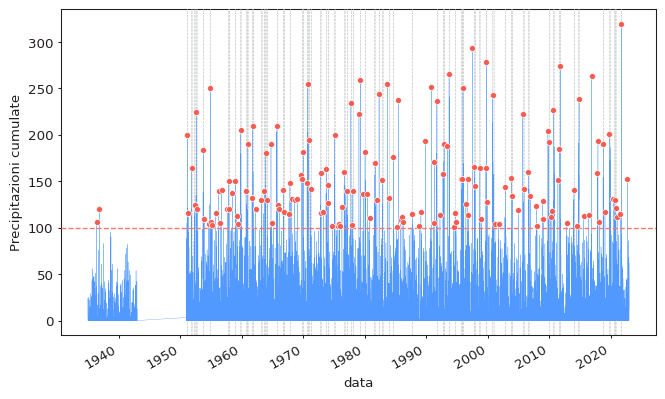

In [17]:
model.plot_extremes(show_clusters=True)

In [18]:
model.extremes.sort_values(ascending=False)

data
2021-10-04    319.60
1997-06-27    293.40
1999-10-25    278.00
2011-10-25    273.80
1993-09-23    265.94
               ...  
2008-01-12    101.80
1974-09-29    101.60
1988-12-02    101.40
1985-03-22    101.10
1994-06-27    101.09
Name: Precipitazioni cumulate, Length: 162, dtype: float64

A questo punto verranno stimati i parametri della GPD, la distribuzione teorica degli eccessi giustificata dal teorema

In [19]:
model.fit_model(distribution="genpareto", distribution_kwargs={})

In [20]:
model

                           Univariate Extreme Value Analysis                            
                                      Source Data                                       
----------------------------------------------------------------------------------------
Data label:       Precipitazioni cumulate      Size:                              29,220
Start:                       January 1935      End:                        December 2022
                                     Extreme Values                                     
----------------------------------------------------------------------------------------
Count:                                162      Extraction method:                    POT
Type:                                high      Threshold:                            100
                                         Model                                          
----------------------------------------------------------------------------------------
Model:               

Vediamo di seguito la stima dei livelli di ritorno, ossia i valori di precipitazione che ci si aspetta vengano superati in media una volta ogni T anni, con T=1,2,5,10 e 100 anni, i grafici relativi ai periodi di ritorno e densità di probabilità e infine i plot P-P e Q-Q

In [21]:
summary = model.get_summary(
    return_period=[1, 2, 5, 10, 100],
    alpha=0.95, # intervallo di confidenza
    n_samples=1000, # campioni utilizzati per la stima
)

In [22]:
summary

,return value,lower ci,upper ci
return period,,,
1.0,179.114523,127.009313,183.351941
2.0,234.588334,160.958190,239.175520
5.0,275.912176,203.607624,279.358416
10.0,293.256343,227.990145,305.375916
100.0,314.885856,266.383814,551.855679


## Osservazione
Il valore più estremo mai registrato, $\sim 320$ mm (tra l'altro molto recentemente nel 2021) ha un periodo di ritorno stimato di più di 100 anni !!

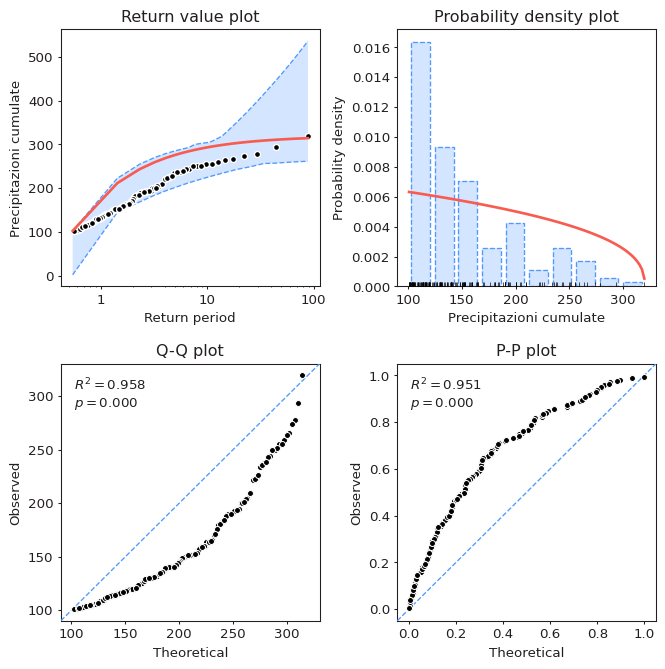

In [23]:
model.plot_diagnostic(alpha=0.95)
plt.show()

Effettuiamo uno zoom sulla pdf della GPD ottenuta tramite il fit del modello : non sempbra adattarsi troppo bene ai dati

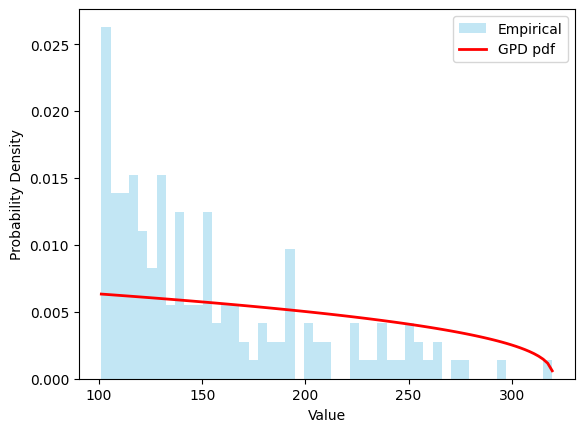

In [24]:
x = np.linspace(min(model.extremes), max(model.extremes), 100)
shape = -0.722
loc = 101.090
scale = 158.099
pdf = genpareto.pdf(x, c=shape, loc=loc, scale=scale)
plt.hist(model.extremes, bins=np.linspace(min(model.extremes), max(model.extremes)),density=True, alpha=0.5, color='skyblue', label='Empirical')
plt.plot(x, pdf, 'r-', lw=2, label='GPD pdf')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

In [25]:
model.distribution

              pyextremes distribution               
----------------------------------------------------
name: genpareto                                     
free parameters: c, loc, scale                      
fixed parameters: all parameters are free           
MLE parameters: c=-0.722, loc=101.090, scale=158.099
----------------------------------------------------

In [26]:
model2=EVA(data_)

In [27]:
model2.get_extremes("POT", threshold=100, r="30D")

In [28]:
model2.fit_model()

In [29]:
model2

                           Univariate Extreme Value Analysis                            
                                      Source Data                                       
----------------------------------------------------------------------------------------
Data label:       Precipitazioni cumulate      Size:                              29,220
Start:                       January 1935      End:                        December 2022
                                     Extreme Values                                     
----------------------------------------------------------------------------------------
Count:                                162      Extraction method:                    POT
Type:                                high      Threshold:                            100
                                         Model                                          
----------------------------------------------------------------------------------------
Model:               

In [30]:
summary2 = model2.get_summary(
    return_period=[1, 2, 5, 10,100],
    alpha=0.95, # intervallo di confidenza
    n_samples=1000, # campioni utilizzati per la stima
)
summary2

,return value,lower ci,upper ci
return period,,,
1.0,135.836256,128.565404,144.758974
2.0,172.758284,160.498364,186.772111
5.0,216.039923,200.966967,231.024681
10.0,245.054403,228.138251,260.326730
100.0,322.419447,283.733640,368.209291


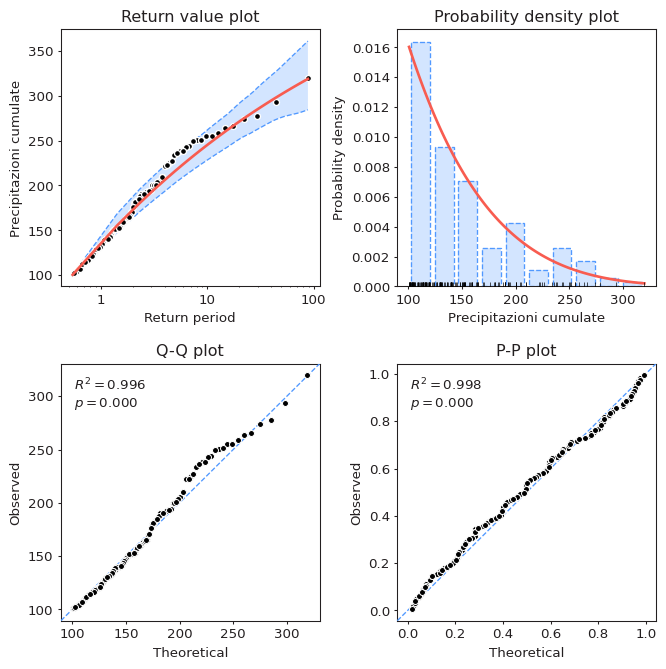

In [31]:
model2.plot_diagnostic(alpha=0.95)
plt.show()

In [32]:
model2.distribution

       pyextremes distribution        
--------------------------------------
name: genpareto                       
free parameters: c, scale             
fixed parameters: floc=100.000        
MLE parameters: c=-0.150, scale=61.446
--------------------------------------

* Abbiamo analizzato le differenza nel passare distribution_kwargs={} quando si fa il fit della distribuzione degli eccessi sopra soglia.
      Con fit_model() vengono applicate tutte le impostazioni numeriche di default (vincoli su shape, scale, bounds, inizializzazioni), mentre passando un dizionario vuoto per distribution_kwargs vengono  sovrascritti i valori di default usati internamente da pyextremes.

* Nel secondo caso i valori sembrano adattarsi troppo bene al modello teorico (probabile situazione di **OVERFITTING**), proprio perchè il fit è influenzato dagli iperparametri

**Stima dei livelli di ritorno**

(Ne diamo di seguito il richiamo teorico considerando un'analisi basata su Block maxima, ma gli stessi risultati si ottengono anche nel caso di POT)

Se denoto con M la variabile massimo annuale di precipitazioni in millimetri, allora il livello di ritorno $R_T$ è quel valore che mi aspetto in media venga superato solamente una volta ogni T anni. $R_T$ soddisfa: 
$$\mathbb{P}(M>R_T)=\frac{1}{T} \quad (*)$$
 Infatti, se vale (*), la variabile che conta gli anni di attesa fino al superamento successivo si comporta come una geometrica (il successo corrisponde a :"il massimo annuale supera $R_T$" e la probabilità di successo è $\frac{1}{T}$) che è risaputo avere valore atteso pari a $\frac{1}{\mathbb{P}(successo)}=T$
 
 Ma $\mathbb{P}(M>R_T)=1-F(R_T)=\frac{1}{T}$, perciò $R_T=F^{-1}\left(1-\frac{1}{T}\right)$, quindi abbiamo ottenuto il livello di ritorno $R_T$ come funzione inversa della fz. di distribuzione stimata dei massimi annuali (questo è il background utilizzato dalla routine get_summary()).

## Periodi di ritorno

(dalla documentazione di pyextremes)

I periodi di ritorno empirici vengono assegnati ai valori estremi osservati seguendo una regola empirica:

* I valori estremi vengono ordinati e classificati dal più estremo (rank 1) al meno estremo (rank n).

* Vengono calcolate le probabilità di superamento corrispondenti.

* I periodi di ritorno vengono infine calcolati come multipli di una unità di tempo di riferimento (return_period_size), tipicamente 1 anno.

 Le probabilità di superamento assegnate ai valori estremi estratti con i metodi Block Maxima (BM) o POT vengono calcolate tramite la seguente formula:

  $$P=\frac{r-\alpha}{n+1-\alpha-\beta} $$

  dove

* r = rank del valore estremo (da 1 a n).

* n = numero totale di valori estremi estratti

* $\alpha,\beta=$ coefficienti empirici **plotting position** (vedi sotto)

  I periodi di ritorno T sono calcolati tramite le probabilità di superamento con la formula :

  $$ T=\frac{1}{P}\frac{1}{\lambda}$$

  con $\lambda=$**Tasso di eventi estremi** (numero medio di eventi estremi per unità di periodo di ritorno `return_period_size`).  
  Per **Peaks Over Threshold (POT)**   viene calcolato come:  

    $$\lambda = \frac{n}{T_\text{tot}}$$
    

    dove:  
    - $T_\text{tot}$ = durata totale della serie da cui sono stati estratti gli estremi

## Plotting positions:
- Insieme di coefficienti empirici utilizzati per associare ai valori estremi osservati una probabilità di superamento.  
- Sono utili per costruire dei plot in cui i valori estremi estratti vengono messi a confronto con i grafici teorici, ma **non influiscono sul fit** della distribuzione teorica (GEV o GPD).
- Ad esempio nel Return Plot ottenuto con la routine "plot_diagnostic()" vengono confrontati i valori teorici della distribuzione stimata (curve rosse) con i valori osservati, e le plotting positions sono lo strumento attraverso cui avviene il confronto (infatti i punti sono disposti per return period empirico che come abbiamo visto viene calcolato facendo uso delle plotting positions)


In [33]:
return_periods = get_return_periods(
    ts=data_,
    extremes=model.extremes,
    extremes_method="POT",
    extremes_type="high",
    return_period_size="365.2425D",
    plotting_position="weibull",
)

return_periods.sort_values("return period", ascending=False).head()



,Precipitazioni cumulate,exceedance probability,return period
data,,,
2021-10-04,319.60,0.006135,88.542273
1997-06-27,293.40,0.012270,44.271137
1999-10-25,278.00,0.018405,29.514091
2011-10-25,273.80,0.024540,22.135568
1993-09-23,265.94,0.030675,17.708455


Tramite la routine get_return periods, abbiamo ottenuto la stima (EMPIRICA,cioè non basata sul fit del modello) dei periodi di ritorno per ciascuno dei valori ottenuti  tramite model.get_extremes con il metodo POT.Per quanto detto sopra,avrei potuto ottenere una stima dei periodi di ritorno per ogni valore x anche dopo aver effettuato la stima dei parametri del modello GPD, semplicemente computando la fz.di distribuzione F e utilizzando la formula $T=\frac{1}{1-F(x)}$.

## Quali accorgimenti si possono apportare per migliorare il modello ?
* C' è una finestra temporale, circa tra il 1936 e il 1950 in cui molto probabilmente non sono stati registrati i dati (o le registrazioni sono andate perdute)
* E' corretto impostare la threshold a 100 mm?

### Selezione della threshold
La selezione del valore di threshold, è un passaggio molto importante che influenza direttamente la qualità del modello.
l'idea sottostante della selezione della threshold, è simile alla selezione della taglia dei blocchi per BM e consiste nell' ottimizzare il compromesso bias-varianza. Grandi valori della soglia, produrrano pochi valori estremi e porteranno ad un modello con grande varianza mentre bassi valori faranno si che il campione di eccessi sia molto numeroso, impedendo un corretto adattamento alla distribuzione GPD. PyExtremes fornisce diversi grafici diagnostici per facilitare una buona scelta della soglia:
* **Mean Residual Life Plot (MRL plot)**: mostra la media degli eccessi (valori sopra soglia) in funzione della soglia stessa. CRITERIO : scegliere l'intervallo per la threshold in cui il grafico risulta approssimativamente lineare
* **Parameter Stability Plot**: rappresentano i parametri stimati della GPD in funzione della soglia. CRITERIO : Una soglia è appropriata quando i parametri diventano stabili, ossia smettono di oscillare e si assestano intorno a valori costanti
*  **Return Value Stability Plot**: mostra i livelli di ritorno stimati (ad es. per T = 10, 50, 100 anni) al crescere della soglia.CRITERIO : una soglia è adeguata quando le curve diventano relativamente piatte ovvero i livelli di ritorno per un T fissato non dipendono troppo dalla scelta della soglia
*  **Treshold Stability Plot**: Riassume tutti i grafici sopra aggiungendo il grafico dell'AIC score in funzione della threshold per i modelli GPD e Esponenziale. Conviene usarlo come guida alla scelta del modello idoneo (tra GPD e Esponenziale) piuttosto che come strumento di selezione della soglia

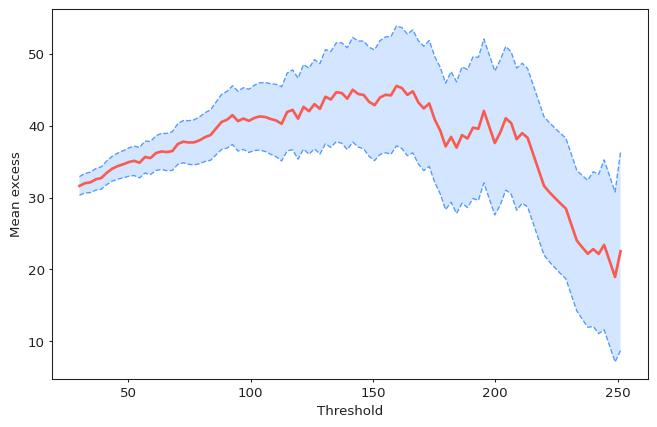

In [34]:
plot_mean_residual_life(data_)
plt.show()

**importante** non lasciare il valore di default per r (24h) ma usare quello impostato per POT

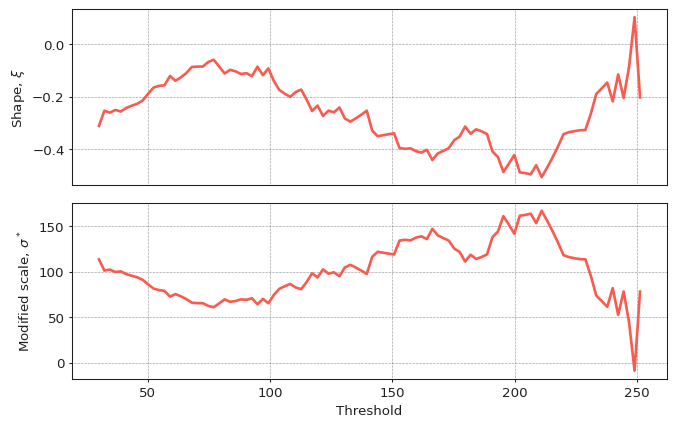

In [35]:
plot_parameter_stability(data_, r="30D")
plt.show()

* L'intervallo tra circa 115 e circa 140 sembra rispettare molto bene il criterio per il Parameter Stability Plot (i parametri rimangono quasi costanti in quell'intervallo) perciò lo settiamo per il Return Value Stability Plot

**importante** non lasciare il valore di default per r (24h) ma usare quello impostato per POT

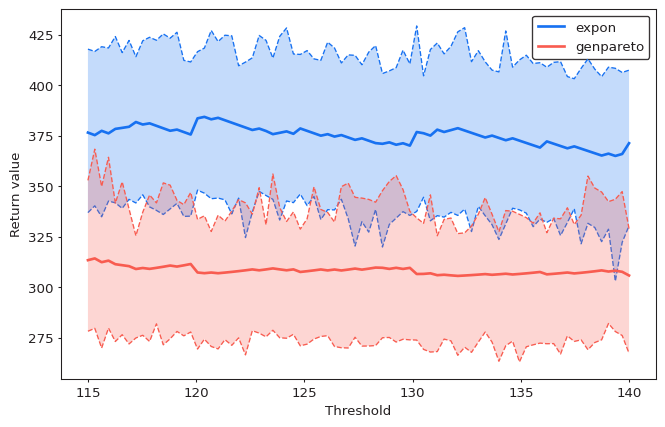

In [36]:
plot_return_value_stability(
    data_,
    return_period=100,
    thresholds=np.linspace(115, 140, 80),
    r="30D",
    alpha=0.95,
)
plt.show()

* Vediamo cosa succede se lascio l'intervallo di default per l' argomento threshold

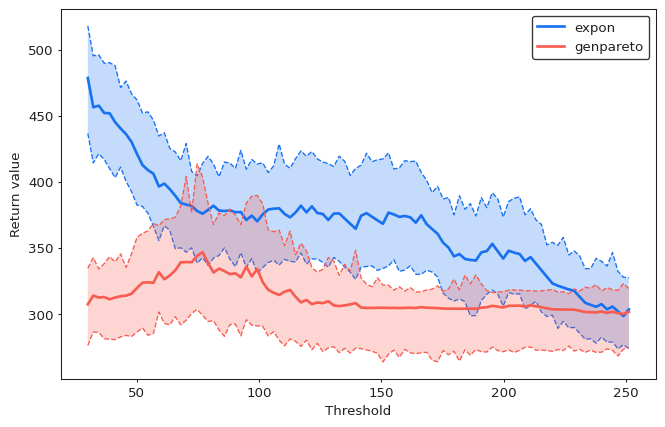

In [37]:
plot_return_value_stability(
    data_,
    return_period=100,
    r="30D",
    alpha=0.95,
)
plt.show()

* Ora settiamo di nuovo 115-140 come intervallo anche per il Threshold Stability Plot

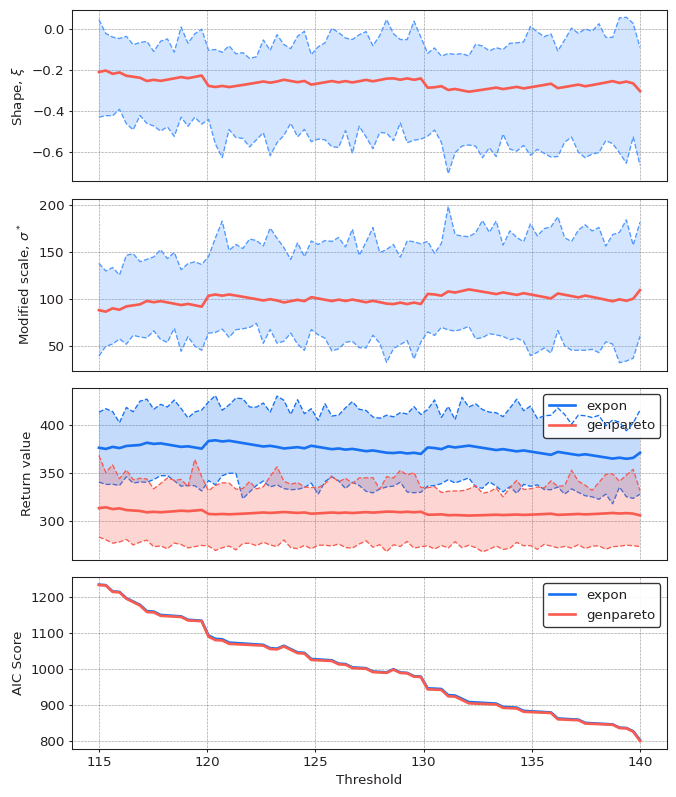

In [38]:
plot_threshold_stability(
    data_,
    return_period=100,
    thresholds=np.linspace(115, 140, 80),
     r="30D",
    alpha=0.95
)
plt.show()

Di nuovo stesso plot precedente ma senza passare l'argomento threshold (quindi lasciando l'intervallo di default)

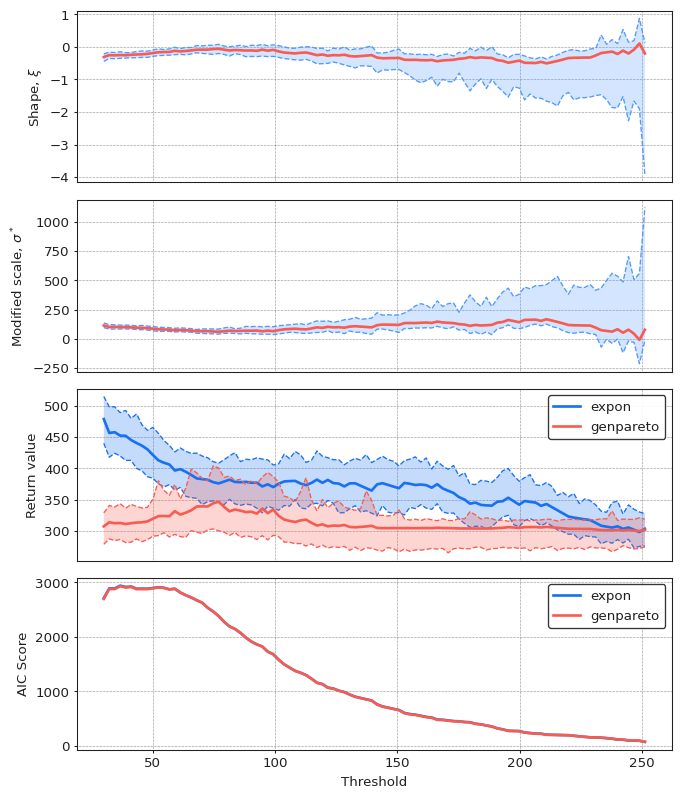

In [39]:
plot_threshold_stability(
    data_,
    return_period=100,
     r="30D",
    alpha=0.95
)
plt.show()

* ora vediamo se migliora l'adattamento al modello settando prima 130 e poi 120 come valori soglia

In [40]:
model3=EVA(data_)

In [41]:
model3.get_extremes("POT",threshold=130,r="30D")

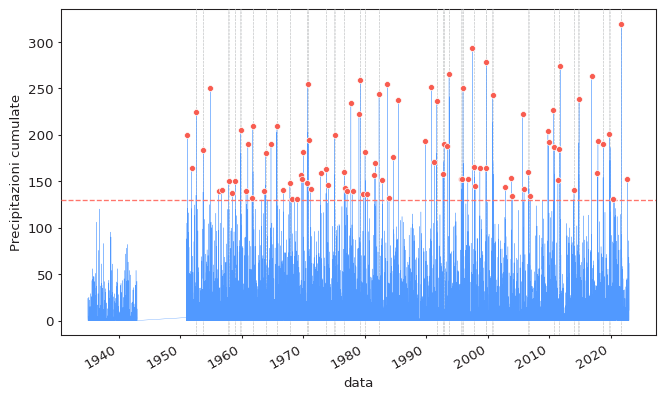

In [42]:
model3.plot_extremes(show_clusters=True)
plt.show()

* **Nota**: Ora gli eccessi sopra soglia iniziano dopo la fine del periodo in cui presumibilmente non sono stati registrati i dati. Invece i dati registrati prima del periodo "vacante" non portano a nessun valore estremo con la nuova soglia

In [43]:
model3.fit_model(distribution="genpareto",distribution_kwargs={})
model3

                           Univariate Extreme Value Analysis                            
                                      Source Data                                       
----------------------------------------------------------------------------------------
Data label:       Precipitazioni cumulate      Size:                              29,220
Start:                       January 1935      End:                        December 2022
                                     Extreme Values                                     
----------------------------------------------------------------------------------------
Count:                                 95      Extraction method:                    POT
Type:                                high      Threshold:                            130
                                         Model                                          
----------------------------------------------------------------------------------------
Model:               

In [44]:
summary3=model.get_summary(
    return_period=[1,2,5,10,100],
    alpha=0.95,
    n_samples=1000,
)
summary3
    

,return value,lower ci,upper ci
return period,,,
1.0,179.114523,127.009313,183.351941
2.0,234.588334,160.958190,239.175520
5.0,275.912176,203.607624,279.358416
10.0,293.256343,227.990145,305.375916
100.0,314.885856,266.383814,551.855679


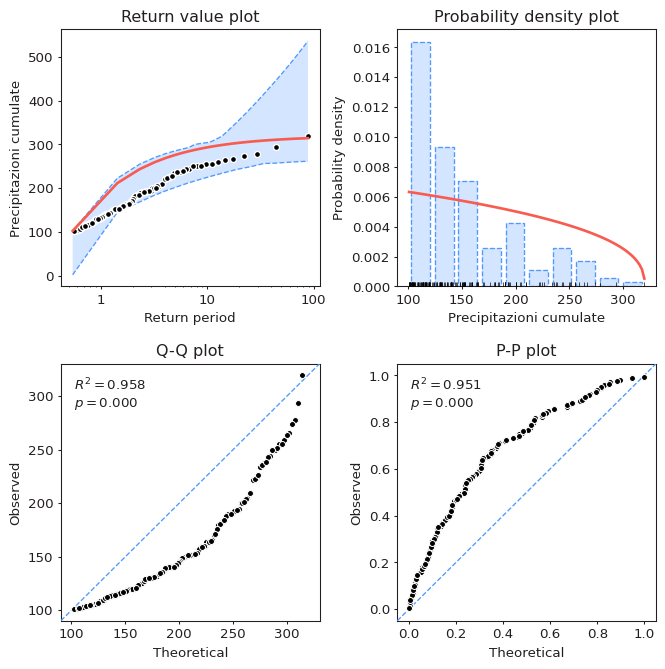

In [45]:
model.plot_diagnostic(alpha=0.95)
plt.show()

In [46]:
model4=EVA(data_)

In [47]:
model4.get_extremes("POT",threshold=120,r="30D")

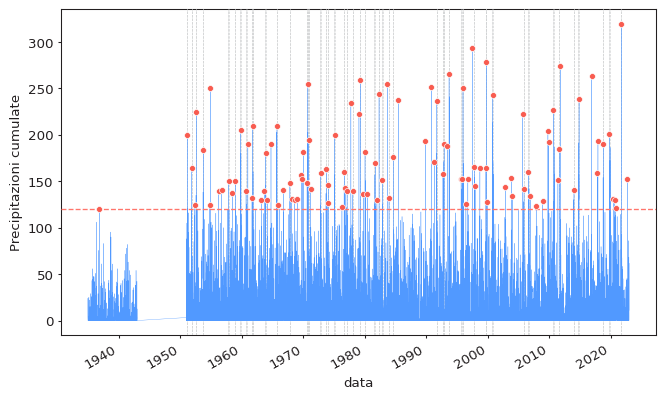

In [48]:
model4.plot_extremes(show_clusters=True)
plt.show()

In [49]:
print(len(model4.extremes))

109


In [50]:
model4.fit_model(distribution="genpareto",distribution_kwargs={})
model4

                           Univariate Extreme Value Analysis                            
                                      Source Data                                       
----------------------------------------------------------------------------------------
Data label:       Precipitazioni cumulate      Size:                              29,220
Start:                       January 1935      End:                        December 2022
                                     Extreme Values                                     
----------------------------------------------------------------------------------------
Count:                                109      Extraction method:                    POT
Type:                                high      Threshold:                            120
                                         Model                                          
----------------------------------------------------------------------------------------
Model:               

In [51]:
summary4=model4.get_summary(
    return_period=[1,2,5,10],
    alpha=0.95,
    n_samples=1000
)
summary4

,return value,lower ci,upper ci
return period,,,
1.0,131.941801,57.476315,157.865530
2.0,170.869380,167.368835,237.637435
5.0,223.706503,210.078566,286.870127
10.0,264.744983,237.988490,303.105685


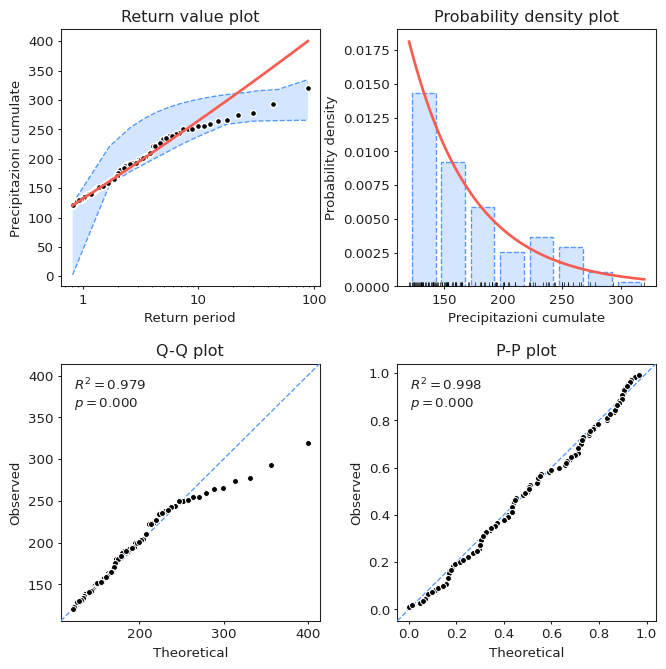

In [52]:
model4.plot_diagnostic(alpha=0.95)
plt.show()

* L'adattamento del modello ai dati sembra decisamente migliore !